In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time

In [37]:
# Let's now change the problem into a regression problem, trying to predict the residual sugar content 
# of the wine instead of its quality. This is a more difficult problem, but it will allow us to see how 
# to use different loss functions and metrics.

In [38]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

data = pd.read_csv(url, sep=";")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
# convert from pandas to tensor
X = torch.tensor(data.drop(["residual sugar"], axis=1).values, dtype=torch.float32)
y = torch.tensor(data["residual sugar"].values, dtype=torch.float32).unsqueeze(1) # unsqueeze to make it a column vector

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

# scale the X_train and y_train with StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = torch.tensor(scaler_X.fit_transform(X_train), dtype=torch.float32)
X_test = torch.tensor(scaler_X.transform(X_test), dtype=torch.float32)
y_train = torch.tensor(scaler_y.fit_transform(y_train), dtype=torch.float32)
y_test = torch.tensor(scaler_y.transform(y_test), dtype=torch.float32)

# create dataloaders
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)
def get_batch_loaders(train_ds, batch_size=16):
    # drop_last=True is used to drop the last batch if it's smaller than the specified batch size,
    # which can help maintain consistent batch sizes during training.
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    return train_dl

In [40]:
class WineQualityModel_Flexible(nn.Module):
    def __init__(self, use_batchnorm=True, act_func=nn.ReLU):
        super().__init__()
        
        # We store these to use in our helper function
        self.use_bn = use_batchnorm
        self.activation = act_func

        # Updated helper function
        def get_block(in_f, out_f):
            layers = []
            
            # 1. Linear Layer (Disable bias if BN is used)
            layers.append(nn.Linear(in_f, out_f, bias=not self.use_bn))
            
            # 2. Optional Batch Norm
            if self.use_bn:
                layers.append(nn.BatchNorm1d(out_f))
            
            # 3. Activation Function (passed as an argument)
            layers.append(self.activation())
            
            return nn.Sequential(*layers)

        # Build the architecture
        self.layer1 = get_block(11, 16)
        self.layer2 = get_block(16, 32)
        self.layer3 = get_block(32, 32)
        
        # Output layer remains linear for regression
        self.fc4 = nn.Linear(32, 1) 

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.fc4(x)
        return x

In [41]:
def train_model(model, learning_rate, train_loader, test_loader, epochs):

    loss_fn = nn.MSELoss() # Mean Squared Error Loss for regression
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    X_test_load, y_test_load = test_loader.dataset.tensors # only need to be done once

    # mse and loss are the same, we should create another list in case we want to track other metrics like R2 score or MAE
    train_loss = torch.zeros(epochs)
    test_loss = torch.zeros(epochs)

    for epoch in range(epochs):

        batch_loss = []
        model.train()

        for X_batch, y_batch in train_loader:
            
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_loss.append(loss.item())
        
        train_loss[epoch] = np.mean(batch_loss)

        # Evaluate on test data
        model.eval() # this will swticth off dropout and batch normalization between layers for the evaluation phase
        with torch.no_grad(): # we don't need gradients for evaluation, which saves memory and computations
            y_pred_test = model(X_test_load)
            test_loss_item = loss_fn(y_pred_test, y_test_load).item()
            test_loss[epoch] = test_loss_item

    return train_loss, test_loss

In [42]:
# Let's compare different activation functions
n_epochs = 1000
learning_rate = 0.01
batch_size = 32

train_loader = get_batch_loaders(train_ds, batch_size=batch_size)

model = WineQualityModel_Flexible(use_batchnorm=False, act_func=nn.ReLU)

train_loss, test_loss = train_model(model, learning_rate, train_loader, test_dl, n_epochs)

In [43]:
# Predictions and inverse transform to original scale
y_pred_test = model(X_test)
y_pred_test = scaler_y.inverse_transform(y_pred_test.detach().numpy())
y_test = scaler_y.inverse_transform(y_test)

y_train_pred = model(X_train)
y_train_pred = scaler_y.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler_y.inverse_transform(y_train)

In [48]:
# correlations
corr_train = np.corrcoef(y_train.flatten(), y_train_pred.flatten())[0, 1]
corr_test = np.corrcoef(y_test.flatten(), y_pred_test.flatten())[0, 1]

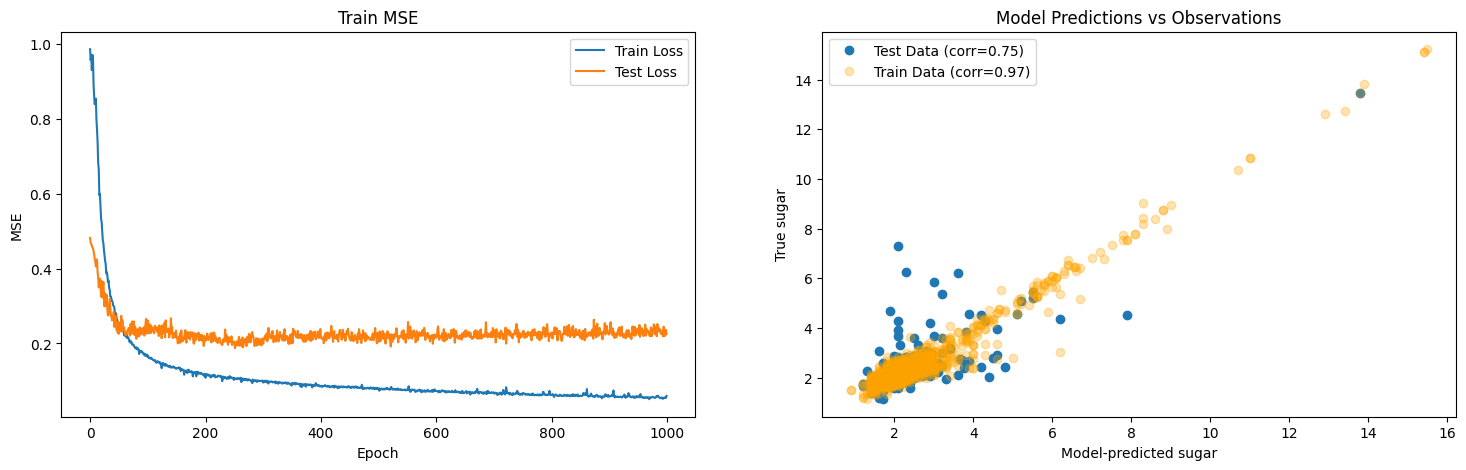

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# plotting train loss vs test loss
ax[0].plot(train_loss, label="Train Loss")
ax[0].plot(test_loss, label="Test Loss")
ax[0].set_title("Train MSE")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE")
ax[0].legend()

# Model prediction vs observations
ax[1].plot(y_test, y_pred_test, "o", alpha=1)
ax[1].plot(y_train, y_train_pred, "o", alpha=0.3, color="orange")
ax[1].set_title("Model Predictions vs Observations")
ax[1].set_xlabel("Model-predicted sugar")
ax[1].set_ylabel("True sugar")
ax[1].legend([f"Test Data (corr={corr_test:.2f})", f"Train Data (corr={corr_train:.2f})"])
plt.show()